### 1. Imports

In [100]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### 2. Read archive

In [101]:
# arquivo anp original -> localizado em data/download_gov/anp.parquet
df = pd.read_parquet("../data/download_gov/anp.parquet")

In [102]:
df.head(2)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,NE,CE,SOBRAL,AUTO POSTO APRAZIVEL LTDA,00.422.849/0001-53,RODOVIA BR 222,S/N,KM 248,SANTA CRUZ DO BANABUIU,00000-000,DIESEL,2004-05-10,1.470,1.507225,R$ / litro,PETROBRAS DISTRIBUIDORA S.A.
1,NE,BA,JAGUAQUARA,LUZITALIA COM. E TRANSP. DE DERIVADOS DE PETRO...,01.073.545/0001-90,AV PRESIDENTE MEDICI N. 150 BR 116 KM640,S/N,GALPAO,ENTRONCAMENTO,00000-000,DIESEL,2004-05-10,1.229,1.153090,R$ / litro,COSAN LUBRIFICANTES


In [103]:
print(f"values nan:\n{df.isna().sum()}\n",'=-='*15)
print(f"type columns:\n{df.info()}\n",'=-='*15)
print(f"values duplicates:\n{df[df.duplicated()].value_counts()}\n")

values nan:
Regiao - Sigla         472856
Estado - Sigla              0
Municipio                   0
Revenda                     0
CNPJ da Revenda             0
Nome da Rua                 0
Numero Rua               8706
Complemento          18744969
Bairro                  55215
Cep                         0
Produto                     0
Data da Coleta              0
Valor de Venda              0
Valor de Compra       6944234
Unidade de Medida           1
Bandeira                    1
dtype: int64
 =-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24694411 entries, 0 to 24694410
Data columns (total 16 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Regiao - Sigla     object        
 1   Estado - Sigla     object        
 2   Municipio          object        
 3   Revenda            object        
 4   CNPJ da Revenda    object        
 5   Nome da Rua        object        
 6   Numero Rua      

In [104]:
df["Produto"].value_counts()

Produto
GLP                   6050559
GASOLINA              5739676
ETANOL                5206422
DIESEL                3741442
DIESEL S10            2363834
GASOLINA ADITIVADA    1206985
GNV                    365360
DIESEL S50              20133
Name: count, dtype: int64

In [105]:
# Agregação mensal por produto e estado — sua base de trabalho principal
df['Data da Coleta'] = pd.to_datetime(df['Data da Coleta'])
df['ano_mes'] = df['Data da Coleta'].dt.to_period('M')

df_agg = (
    df.groupby(['ano_mes', 'Estado - Sigla', 'Produto'])
    ['Valor de Venda']
    .agg(media='mean', mediana='median', desvio='std', contagem='count')
    .reset_index()
)

# Para análises de distribuição que precisam de pontos individuais
df_sample = df.sample(100_000, random_state=42)

## 3. Graphics

#### 3.1. Distribuição de preços por produto — ANP

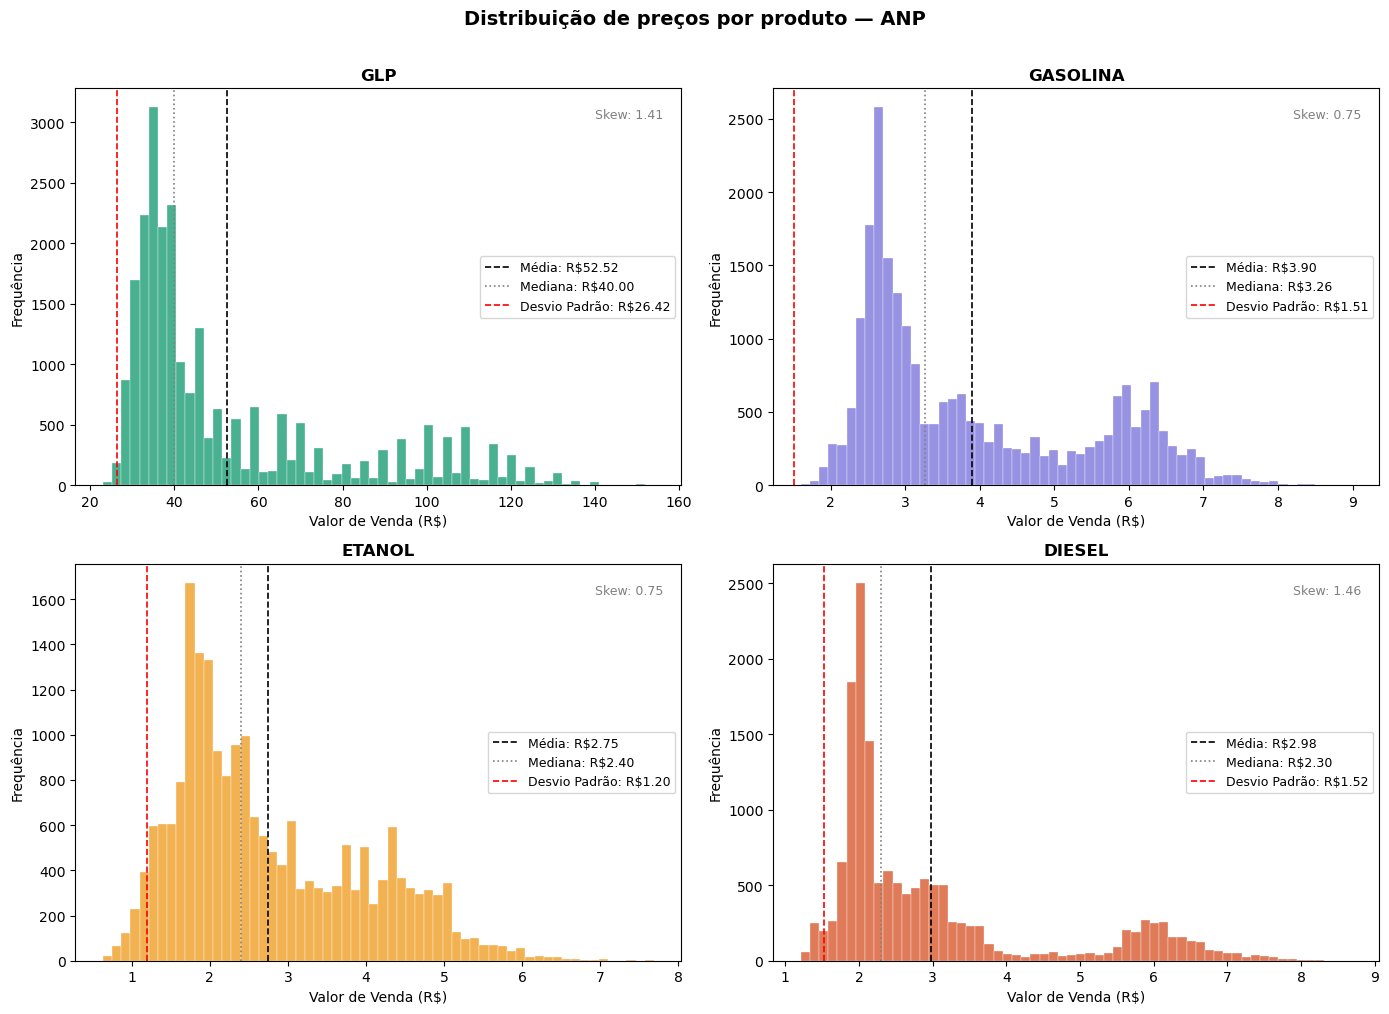

In [106]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
produtos = ['GLP','GASOLINA','ETANOL','DIESEL']
cores = ['#1D9E75', '#7F77DD', '#EF9F27', '#D85A30']

for ax, produto, cor in zip(axes.flatten(), produtos, cores):
    dados = df_sample[df_sample['Produto'] == produto]['Valor de Venda'].dropna()
    
    ax.hist(dados, bins=60, color=cor, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(dados.mean(),   color='black', linestyle='--', linewidth=1.2, label=f'Média: R${dados.mean():.2f}')
    ax.axvline(dados.median(), color='gray',  linestyle=':',  linewidth=1.2, label=f'Mediana: R${dados.median():.2f}')
    # applying std to see data dispersion 
    ax.axvline(dados.std(), color='red',  linestyle='--',  linewidth=1.2, label=f'Desvio Padrão: R${dados.std():.2f}')

    ax.set_title(produto, fontsize=12, fontweight='bold')
    ax.set_xlabel('Valor de Venda (R$)')
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=9)
    
    # Skewness no canto
    skew = dados.skew()
    ax.text(0.97, 0.95, f'Skew: {skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='gray')

plt.suptitle('Distribuição de preços por produto — ANP', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig('distribuicao_produtos.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.2. Distribuição de preços p/ produto - boxplot

C:\Users\ferna\AppData\Local\Temp\ipykernel_34528\3698866427.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


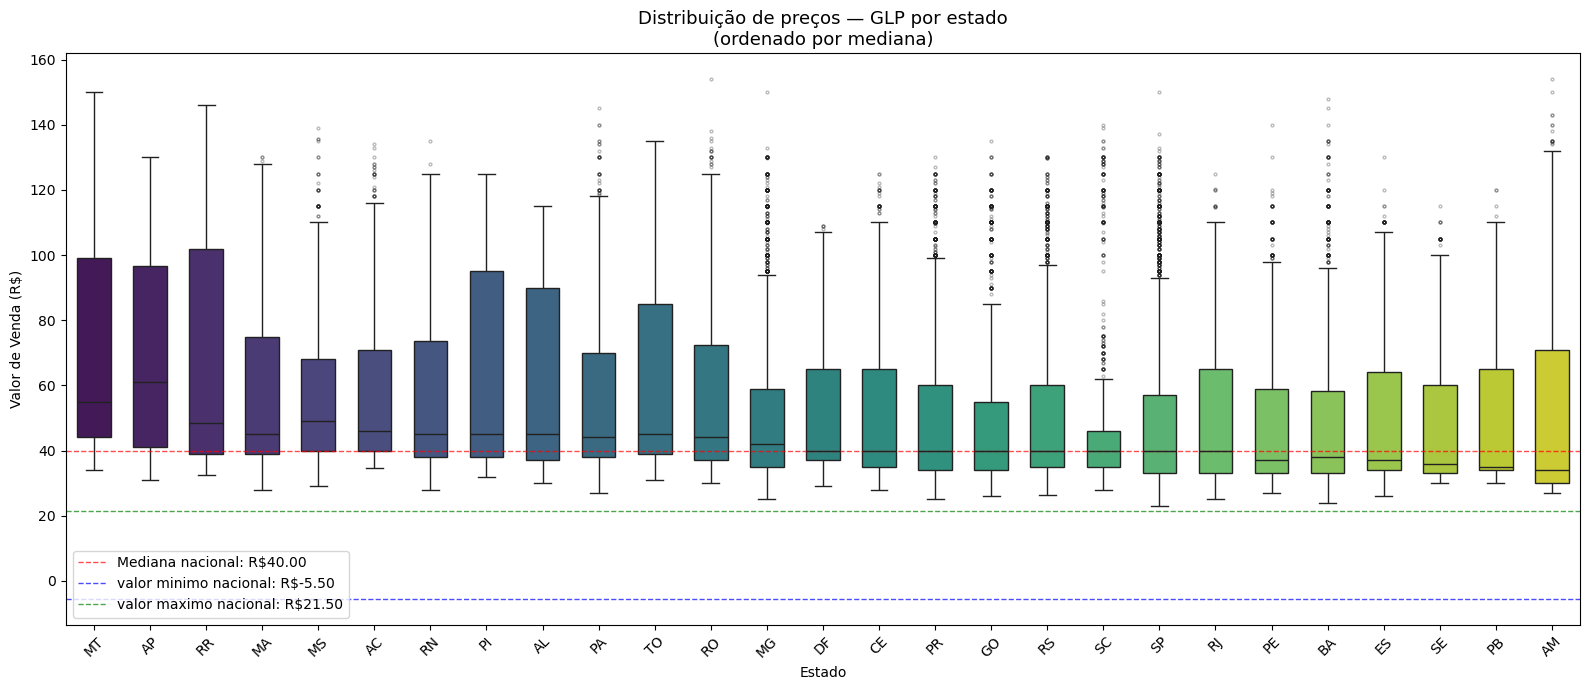

In [107]:
produto_foco = 'GLP'

df_gas = (
    df[df['Produto'] == produto_foco]
    .groupby('Estado - Sigla')['Valor de Venda']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

ordem_estados = df_gas['Estado - Sigla'].tolist()

fig, ax = plt.subplots(figsize=(16, 7))

dados_box = df_sample[df_sample['Produto'] == produto_foco]

sns.boxplot(
    data=dados_box,
    x='Estado - Sigla',
    y='Valor de Venda',
    order=ordem_estados,
    palette='viridis',
    width=0.6,
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_title(f'Distribuição de preços — {produto_foco} por estado\n(ordenado por mediana)', fontsize=13)
ax.set_xlabel('Estado')
ax.set_ylabel('Valor de Venda (R$)')
ax.tick_params(axis='x', rotation=45)

# Linha da mediana nacional
mediana_nacional = dados_box['Valor de Venda'].median()
q1 = dados_box['Valor de Venda'].quantile(0.25)
q3 = dados_box['Valor de Venda'].quantile(0.75)

IQR = q3 - q1
MIN = q1 - 1.5 *IQR
MAX = q3 - 1.5 *IQR
ax.axhline(mediana_nacional, color='red', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Mediana nacional: R${mediana_nacional:.2f}')

ax.axhline(MIN, color='blue', linestyle='--', linewidth=1, alpha=0.7,                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
           label=f'valor minimo nacional: R${MIN:.2f}')

ax.axhline(MAX, color='green', linestyle='--', linewidth=1, alpha=0.7,
           label=f'valor maximo nacional: R${MAX:.2f}')
ax.legend()

plt.tight_layout()
# plt.savefig('boxplot_estados.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.3. Distribuição de preços por produto (violin plot)

C:\Users\ferna\AppData\Local\Temp\ipykernel_34528\2096892364.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ferna\AppData\Local\Temp\ipykernel_34528\2096892364.py:3: UserWarning: 
The palette list has fewer values (4) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(


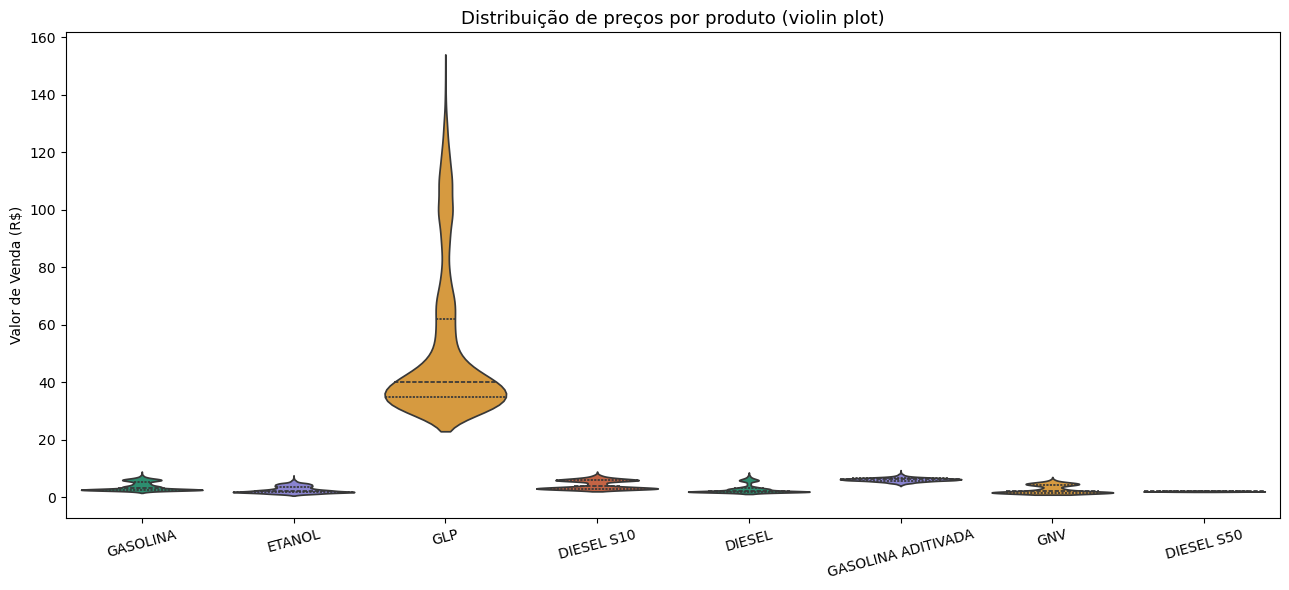

In [108]:
fig, ax = plt.subplots(figsize=(13, 6))

sns.violinplot(
    data=df_sample,
    x='Produto',
    y='Valor de Venda',
    palette=['#1D9E75', '#7F77DD', '#EF9F27', '#D85A30'],
    inner='quartile',   # mostra quartis dentro do violin
    cut=0,              # não extrapola além dos dados reais
    ax=ax
)

ax.set_title('Distribuição de preços por produto (violin plot)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Valor de Venda (R$)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

#### 3.4. Distribuição de preços — Produto × Região

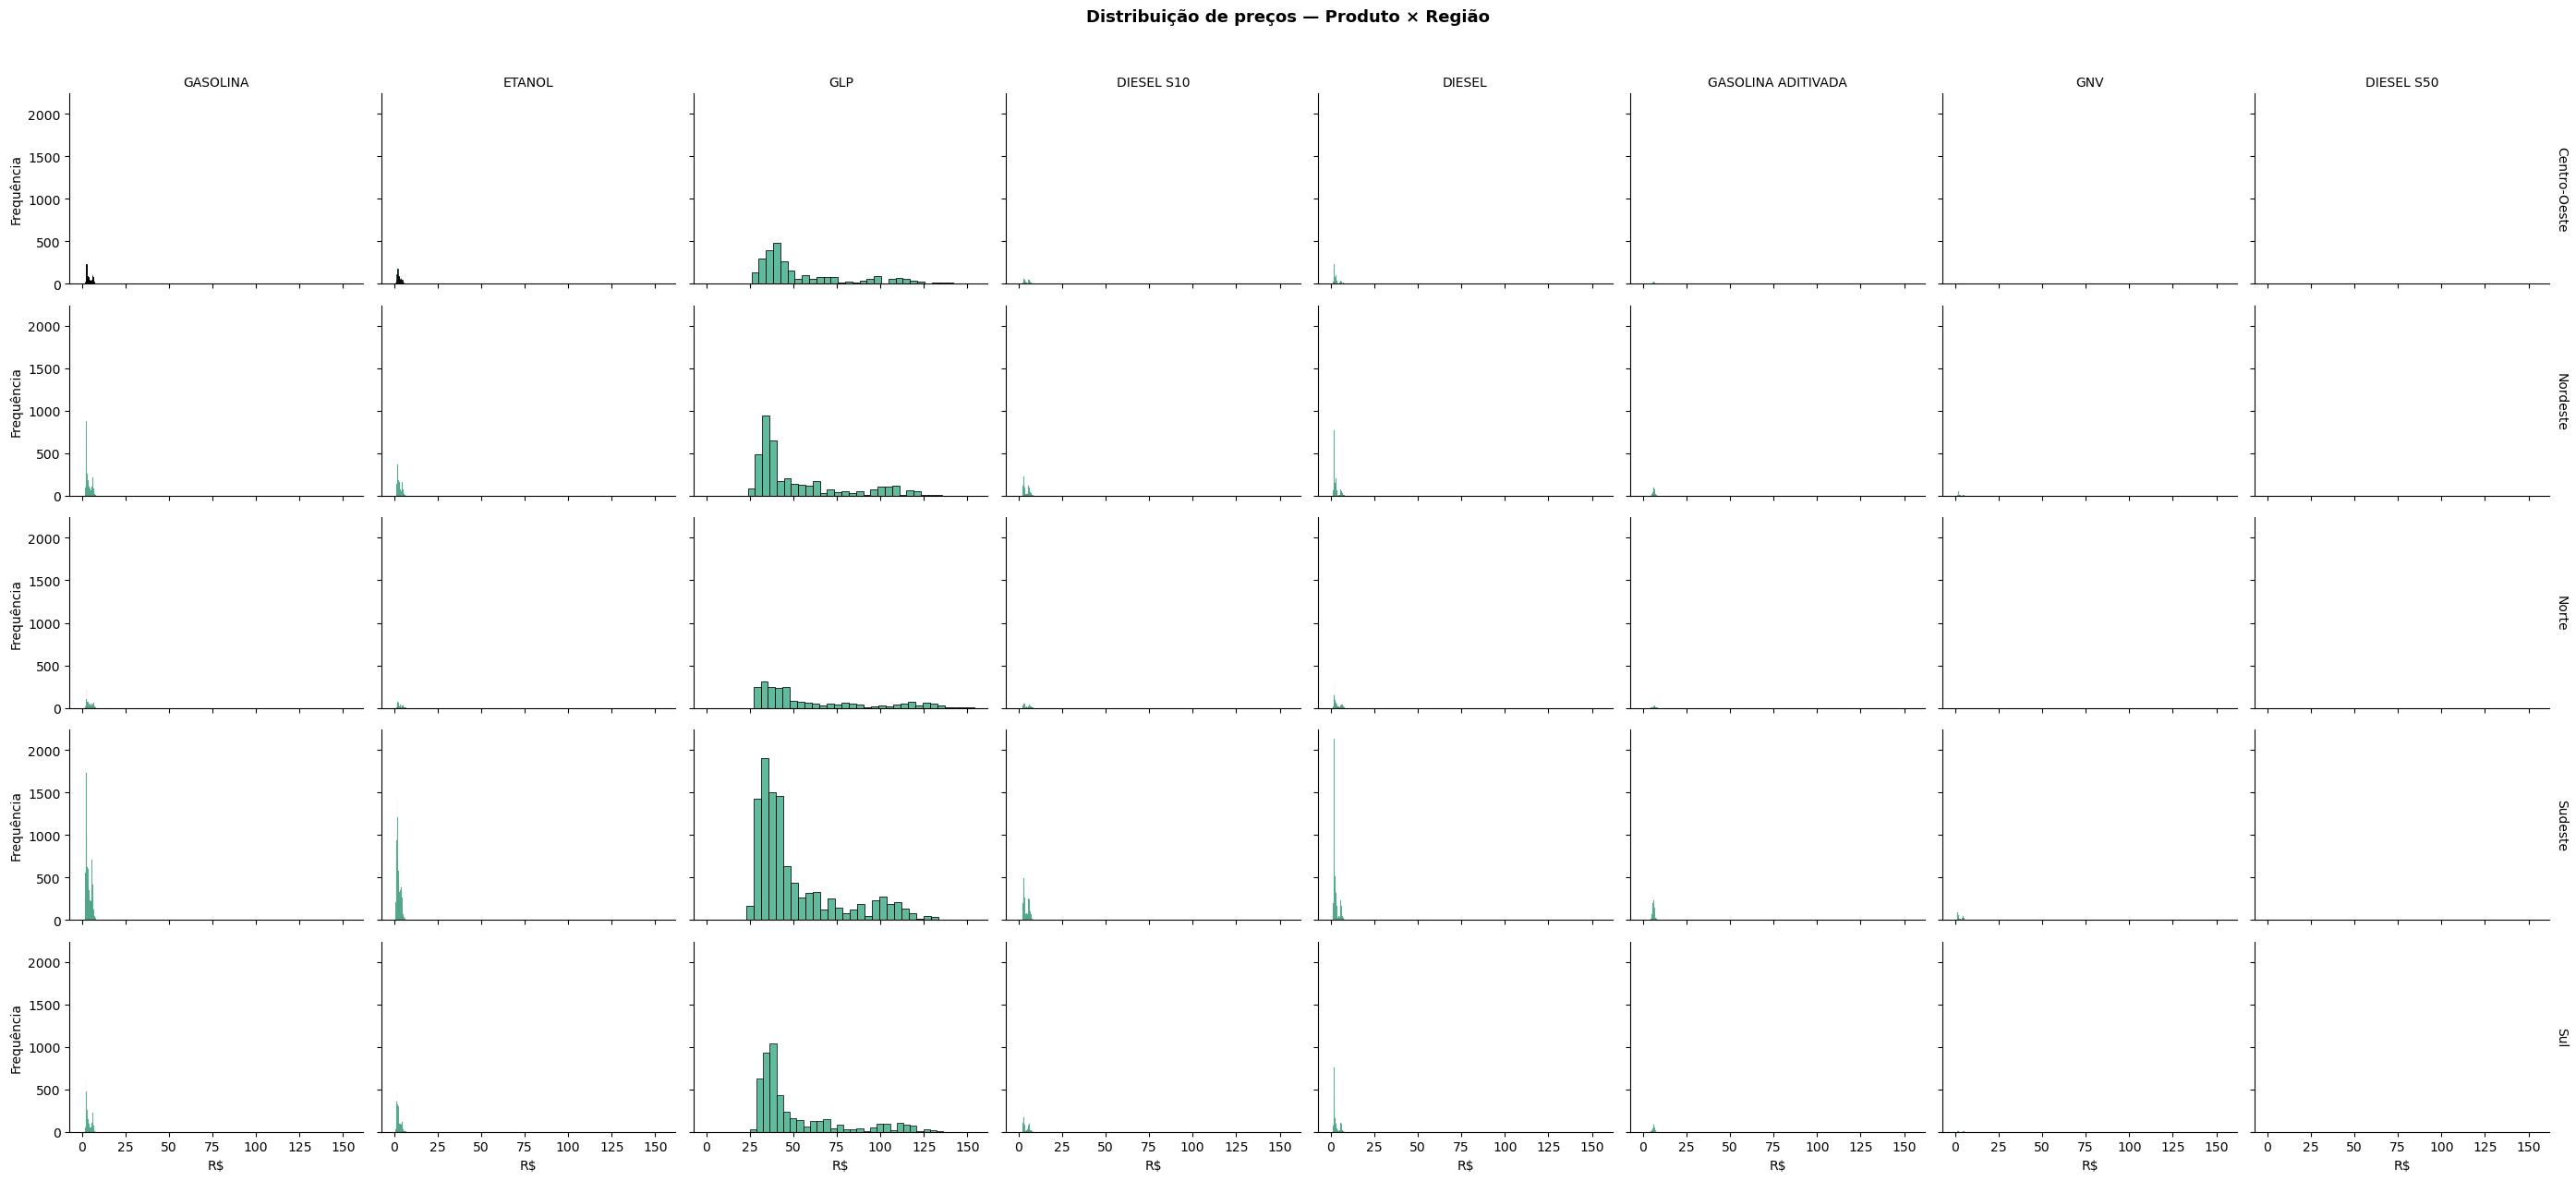

In [109]:
regioes = {
    'Norte': ['AC', 'AP', 'AM', 'PA', 'RO', 'RR', 'TO'],
    'Nordeste': ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'],
    'Centro-Oeste': ['DF', 'GO', 'MT', 'MS'],
    'Sudeste': ['ES', 'MG', 'RJ', 'SP'],
    'Sul': ['PR', 'RS', 'SC']
}
def get_region(state):
    for region, _states in regioes.items():
        if state in _states:
            return region
    return 'Desconhecida'

df_sample['Regiao'] = df_sample['Estado - Sigla'].apply(get_region)

g = sns.FacetGrid(
    df_sample.dropna(subset=['Regiao']),
    col='Produto',
    row='Regiao',
    height=2.5,
    aspect=1.4,
    margin_titles=True
)

g.map(sns.histplot, 'Valor de Venda', bins=30, color='#1D9E75', alpha=0.7)
g.set_titles(col_template='{col_name}', row_template='{row_name}')
g.set_axis_labels('R$', 'Frequência')
g.figure.suptitle('Distribuição de preços — Produto × Região', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('facet_produto_regiao.png', dpi=120, bbox_inches='tight')
plt.show()

No caso a cima vemos um consumo maior na regiao Sudeste, em seguida Sul, Nordeste, Centro-Oeste e por fim Norte. Onde o produto predominante é o GLP, seguido pela gasolina, etanol e diesel.

#### 3.5. Q-Q plots — verificação de normalidade por produto

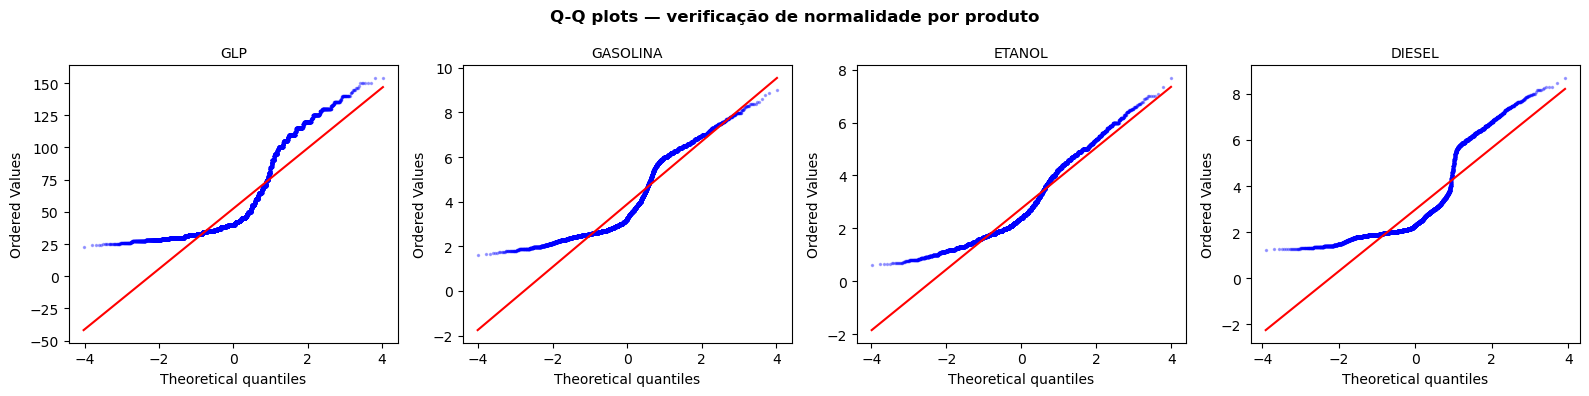

In [110]:
from scipy import stats

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, produto in zip(axes, produtos):
    dados = df_sample[df_sample['Produto'] == produto]['Valor de Venda'].dropna()
    stats.probplot(dados, dist='norm', plot=ax)
    ax.set_title(produto, fontsize=10)
    ax.get_lines()[0].set(markersize=1.5, alpha=0.3)

plt.suptitle('Q-Q plots — verificação de normalidade por produto', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpretação rápida
# Pontos na linha diagonal = normal
# Curva em S = distribuição com caudas pesadas (leptocúrtica)
# Curva em arco = assimetria

#### 3.6. Evolução temporal de preços — média nacional com dispersão

##### 3.6.1. Criando features temporais

In [111]:
df['Data da Coleta'] = pd.to_datetime(df['Data da Coleta'])
df['ano']            = df['Data da Coleta'].dt.year
df['mes']            = df['Data da Coleta'].dt.month
df['semana']         = df['Data da Coleta'].dt.to_period('W')

PRODUTOS = produtos
CORES    = {'GASOLINA': '#1D9E75', 'ETANOL': '#7F77DD',
            'DIESEL': '#EF9F27', 'GLP': '#D85A30'}
# Agregação mensal nacional por produto
ts_nacional = (
    df.groupby(['ano_mes', 'Produto'])['Valor de Venda']
    .agg(media='mean', mediana='median', std='std')
    .reset_index()
)
ts_nacional['ano_mes_dt'] = ts_nacional['ano_mes'].dt.to_timestamp()

# Agregação mensal por produto + estado
ts_estado = (
    df.groupby(['ano_mes', 'Estado - Sigla', 'Produto'])['Valor de Venda']
    .median()
    .reset_index()
)
ts_estado['ano_mes_dt'] = ts_estado['ano_mes'].dt.to_timestamp()


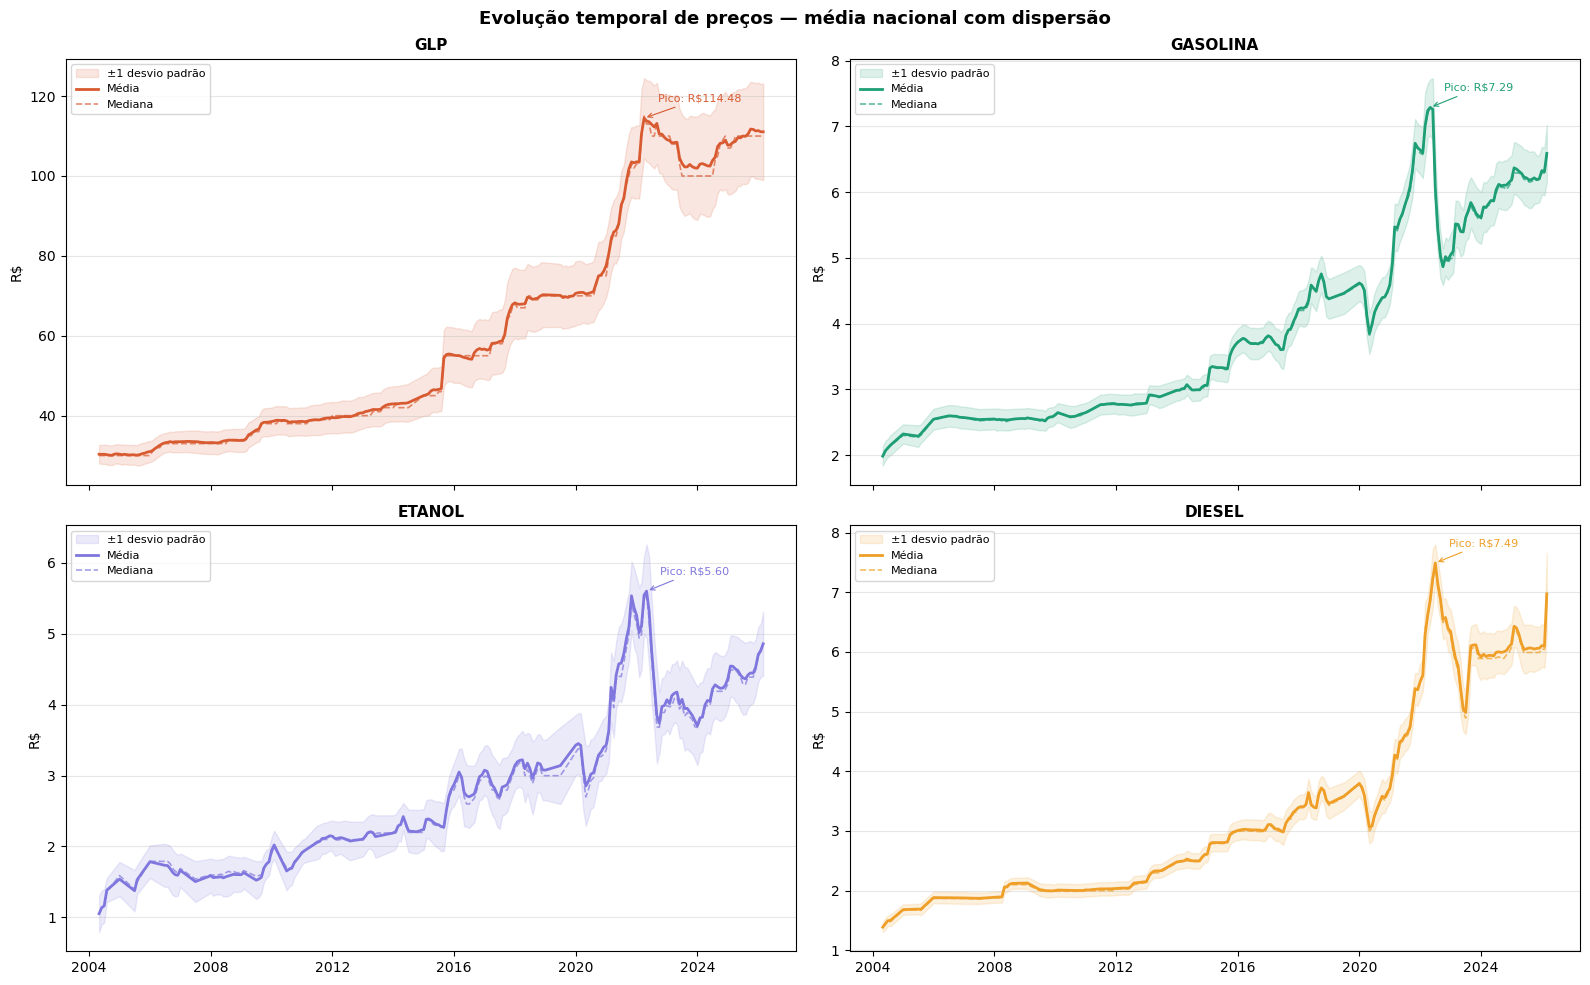

In [112]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

for ax, produto in zip(axes.flatten(), PRODUTOS):
    dados = ts_nacional[ts_nacional['Produto'] == produto].sort_values('ano_mes_dt')
    
    cor   = CORES[produto]

    ax.fill_between(
        dados['ano_mes_dt'],
        dados['media'] - dados['std'],
        dados['media'] + dados['std'],
        alpha=0.15, color=cor, label='±1 desvio padrão'
    )
    ax.plot(dados['ano_mes_dt'], dados['media'],   color=cor,   lw=2,   label='Média')
    ax.plot(dados['ano_mes_dt'], dados['mediana'], color=cor,   lw=1.2,
            linestyle='--', alpha=0.7, label='Mediana')

    # Anotação do pico
    idx_pico = dados['media'].idxmax()
    pico     = dados.loc[idx_pico]
    ax.annotate(
        f"Pico: R${pico['media']:.2f}",
        xy=(pico['ano_mes_dt'], pico['media']),
        xytext=(10, 12), textcoords='offset points',
        fontsize=8, color=cor,
        arrowprops=dict(arrowstyle='->', color=cor, lw=0.8)
    )

    ax.set_title(produto, fontsize=11, fontweight='bold')
    ax.set_ylabel('R$')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

plt.suptitle('Evolução temporal de preços — média nacional com dispersão', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('linha_tempo_nacional.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.7. Evolução por estado — dispersão regional ao longo do tempo

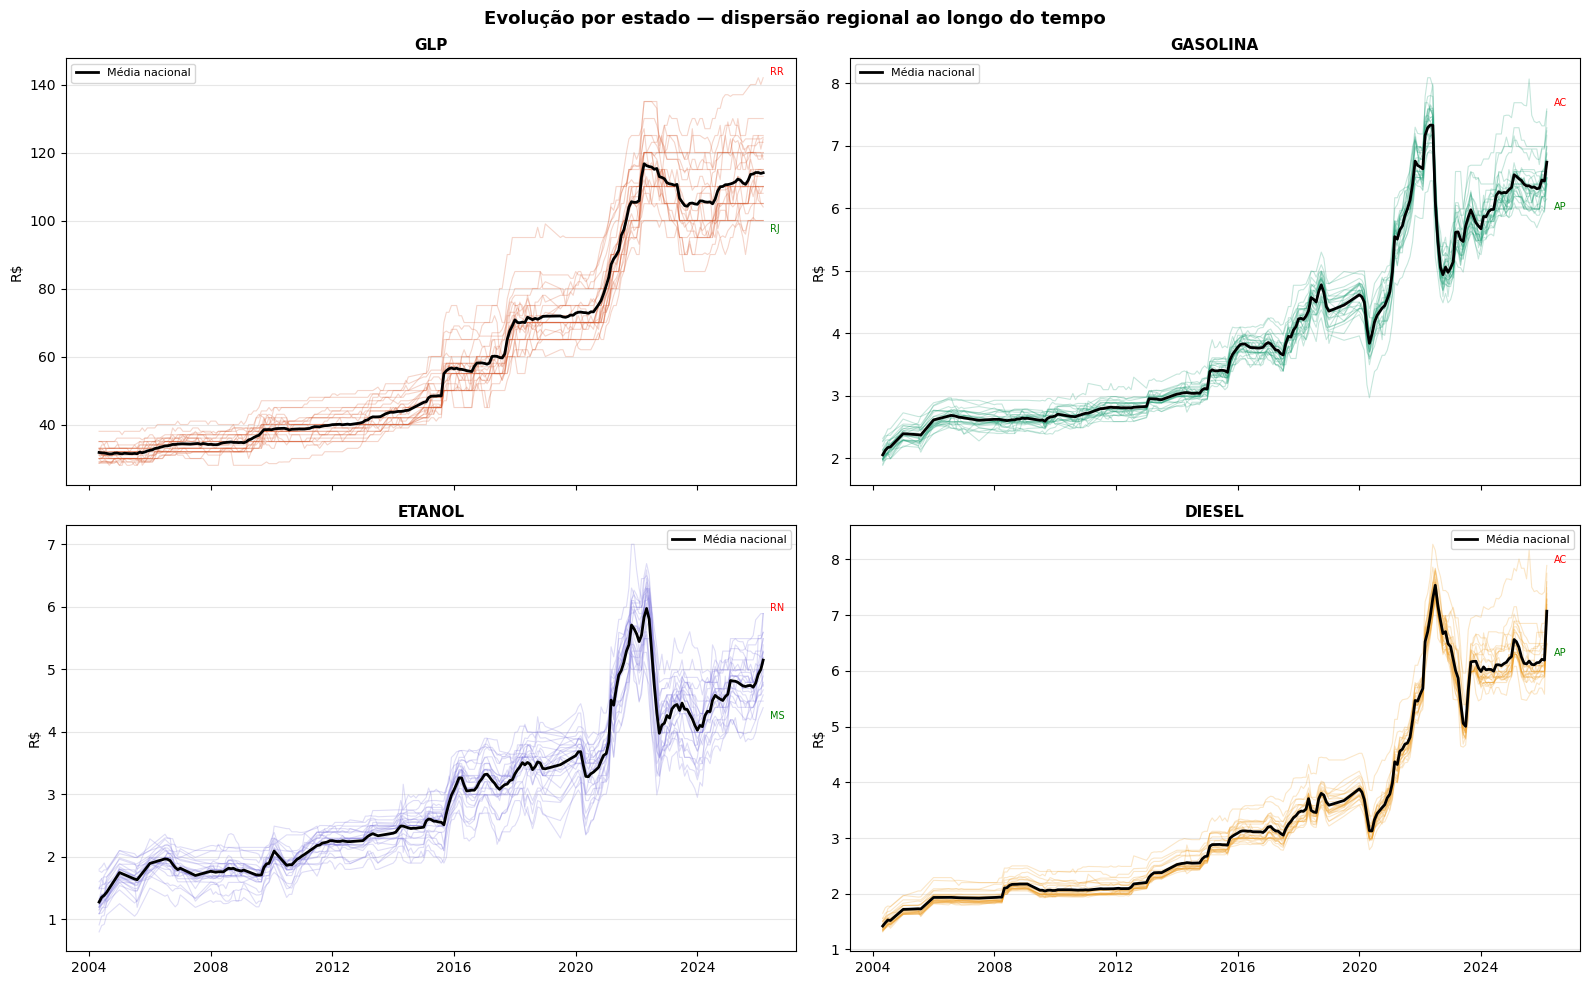

In [113]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

for ax, produto in zip(axes.flatten(), PRODUTOS):
    dados = ts_estado[ts_estado['Produto'] == produto].sort_values('ano_mes_dt')

    estados     = dados['Estado - Sigla'].unique()
    media_nac   = dados.groupby('ano_mes_dt')['Valor de Venda'].mean()

    # Linhas finas por estado
    for uf in estados:
        d = dados[dados['Estado - Sigla'] == uf]
        ax.plot(d['ano_mes_dt'], d['Valor de Venda'],
                alpha=0.25, lw=0.8, color=CORES[produto])

    # Média nacional em destaque
    ax.plot(media_nac.index, media_nac.values,
            color='black', lw=2, label='Média nacional', zorder=5)

    # Destaca o estado mais caro e mais barato no último período
    ultimo = dados[dados['ano_mes_dt'] == dados['ano_mes_dt'].max()]
    if not ultimo.empty:
        mais_caro   = ultimo.loc[ultimo['Valor de Venda'].idxmax()]
        mais_barato = ultimo.loc[ultimo['Valor de Venda'].idxmin()]
        ax.annotate(mais_caro['Estado - Sigla'],
                    xy=(mais_caro['ano_mes_dt'], mais_caro['Valor de Venda']),
                    fontsize=7, color='red', xytext=(5, 2), textcoords='offset points')
        ax.annotate(mais_barato['Estado - Sigla'],
                    xy=(mais_barato['ano_mes_dt'], mais_barato['Valor de Venda']),
                    fontsize=7, color='green', xytext=(5, -8), textcoords='offset points')

    ax.set_title(produto, fontsize=11, fontweight='bold')
    ax.set_ylabel('R$')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Evolução por estado — dispersão regional ao longo do tempo', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('spaghetti_estados.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.8. Heatmap de preços - por estado ao longo do tempo

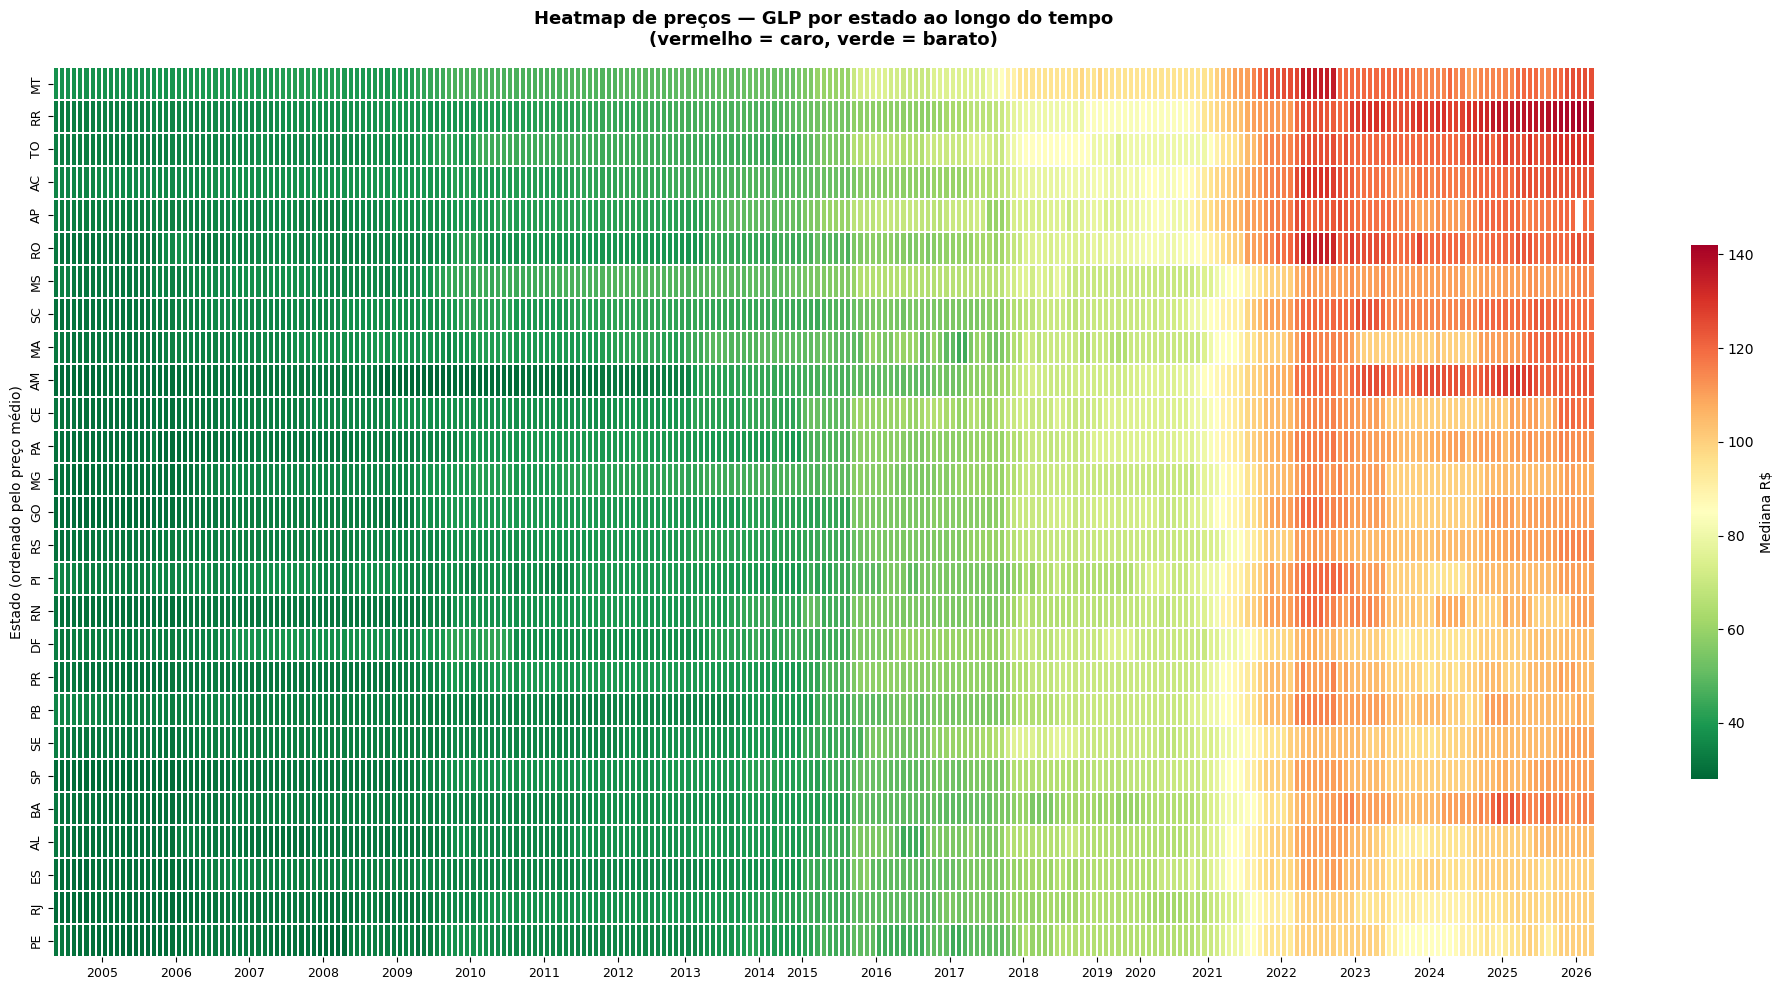

In [114]:
produto_foco = 'GLP'

# Pivot: estados nas linhas, anos/meses nas colunas
pivot = (
    ts_estado[ts_estado['Produto'] == produto_foco]
    .assign(periodo=lambda x: x['ano_mes'].astype(str))
    .pivot_table(index='Estado - Sigla', columns='periodo',
                 values='Valor de Venda', aggfunc='median')
)

# Ordena estados pela média geral (mais caro no topo)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(20, 10))

sns.heatmap(
    pivot,
    cmap='RdYlGn_r',     # vermelho = caro, verde = barato
    ax=ax,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Mediana R$', 'shrink': 0.6},
    fmt='.2f',
    annot=False           # True se quiser ver os valores (fica pesado)
)

# Reduz labels do eixo x para mostrar só os anos
labels_x = pivot.columns.tolist()
ticks_anos = [i for i, l in enumerate(labels_x) if l.endswith('-01')]
ax.set_xticks(ticks_anos)
ax.set_xticklabels([labels_x[i][:4] for i in ticks_anos], rotation=0, fontsize=9)

ax.set_title(f'Heatmap de preços — {produto_foco} por estado ao longo do tempo\n(vermelho = caro, verde = barato)',
             fontsize=13, fontweight='bold', pad=16)
ax.set_xlabel('')
ax.set_ylabel('Estado (ordenado pelo preço médio)', fontsize=10)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
# plt.savefig('heatmap_estado_tempo.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.9. Sazonalidade mensal de preços por produto

C:\Users\ferna\AppData\Local\Temp\ipykernel_34528\3998345368.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\ferna\AppData\Local\Temp\ipykernel_34528\3998345368.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\ferna\AppData\Local\Temp\ipykernel_34528\3998345368.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\ferna\AppData\Local\Temp\ipykernel_34528\3998345368.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.l

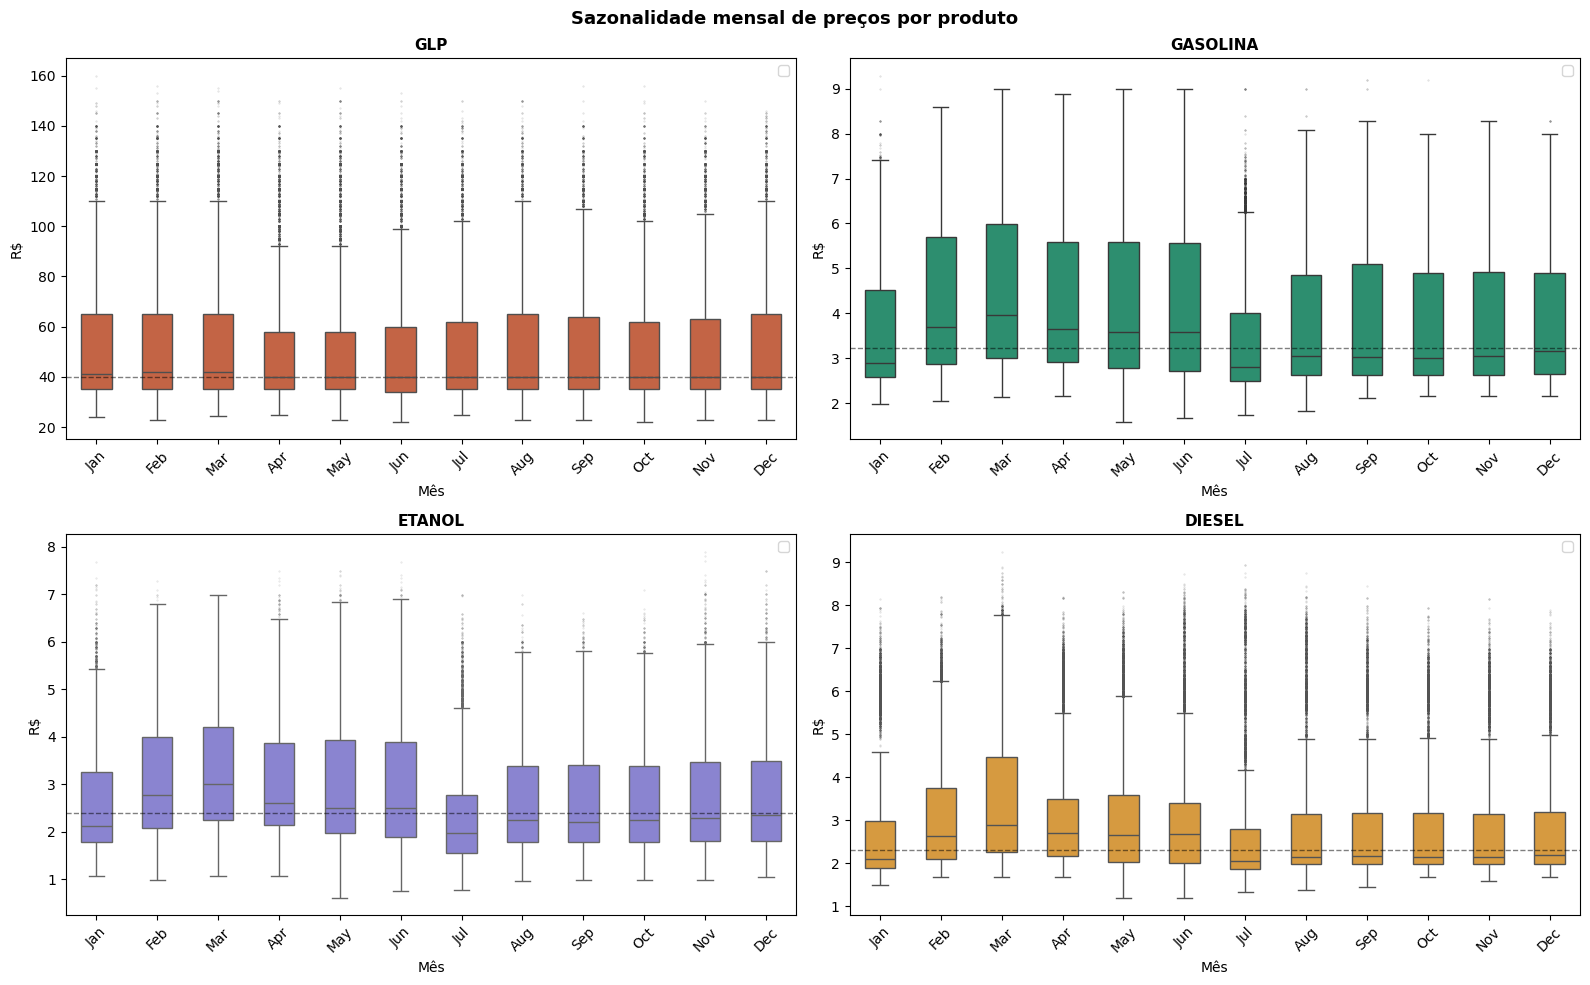

In [115]:
df['mes_nome'] = df['Data da Coleta'].dt.strftime('%b')  # Jan, Fev...
ordem_meses   = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, produto in zip(axes.flatten(), PRODUTOS):
    dados = df[df['Produto'] == produto].sample(min(200_000, len(df)), random_state=42)

    sns.boxplot(
        data=dados,
        x='mes_nome',
        y='Valor de Venda',
        order=ordem_meses,
        color=CORES[produto],
        width=0.5,
        flierprops=dict(marker='.', markersize=1, alpha=0.2),
        ax=ax
    )

    # Linha da mediana geral como referência
    mediana_geral = dados['Valor de Venda'].median()
    ax.axhline(mediana_geral, color='black', linestyle='--', lw=1, alpha=0.5)
    ax.legend()
    ax.set_title(produto, fontsize=11, fontweight='bold')
    ax.set_xlabel('Mês')
    ax.set_ylabel('R$')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Sazonalidade mensal de preços por produto', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('sazonalidade_mensal.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.10. Decomposição STL

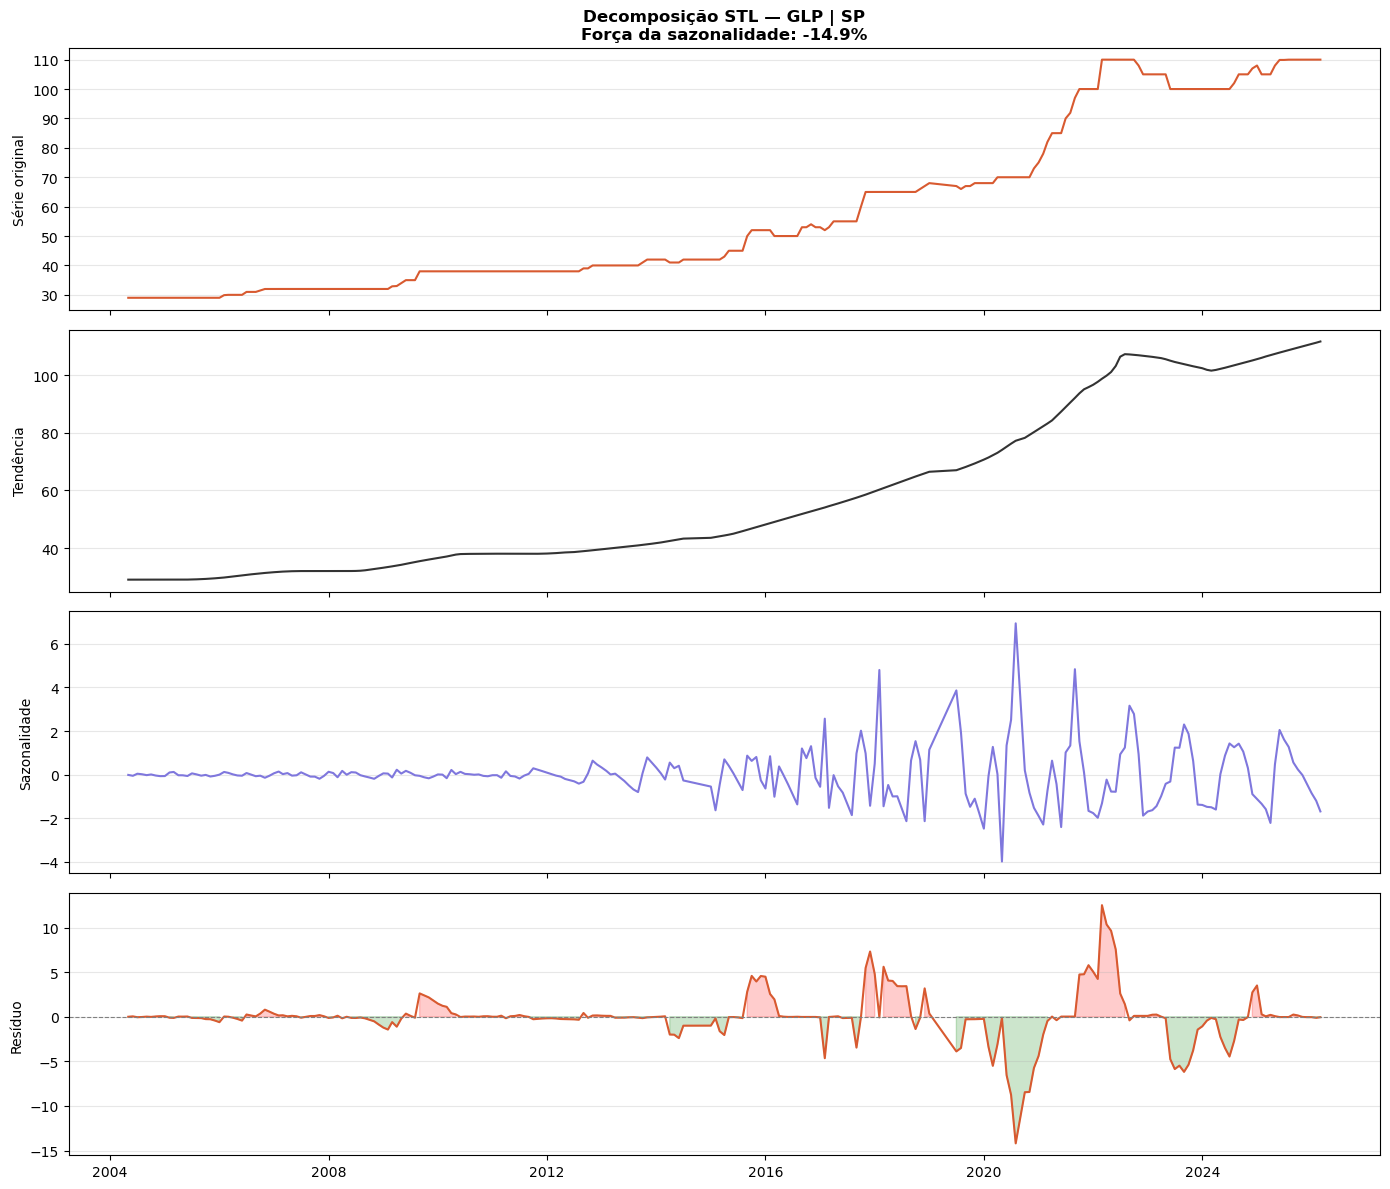


=== Força da sazonalidade por produto (SP) ===
  GLP                       -14.9%
  GASOLINA                  -5.2%
  ETANOL                    9.7%
  DIESEL                    2.5%


In [116]:
from statsmodels.tsa.seasonal import STL

produto_foco = 'GLP'
estado_foco  = 'SP'

# Série mensal para um estado específico
serie = (
    df[(df['Produto'] == produto_foco) & (df['Estado - Sigla'] == estado_foco)]
    .groupby('ano_mes')['Valor de Venda']
    .median()
    .reset_index()
    .sort_values('ano_mes')
)
serie.index = serie['ano_mes'].dt.to_timestamp()
serie_vals  = serie['Valor de Venda'].dropna()

# STL com período anual (12 meses)
stl    = STL(serie_vals, period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
componentes = [
    (serie_vals,         'Série original',  CORES[produto_foco]),
    (result.trend,       'Tendência',       '#333333'),
    (result.seasonal,    'Sazonalidade',    '#7F77DD'),
    (result.resid,       'Resíduo',         '#D85A30'),
]

for ax, (dados, titulo, cor) in zip(axes, componentes):
    ax.plot(dados.index, dados.values, color=cor, lw=1.5)
    if titulo == 'Resíduo':
        ax.axhline(0, color='gray', lw=0.8, linestyle='--')
        ax.fill_between(dados.index, dados.values, 0,
                        where=dados.values > 0, color='red',  alpha=0.2)
        ax.fill_between(dados.index, dados.values, 0,
                        where=dados.values < 0, color='green', alpha=0.2)
    ax.set_ylabel(titulo, fontsize=10)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_title(
    f'Decomposição STL — {produto_foco} | {estado_foco}\n'
    f'Força da sazonalidade: {1 - result.resid.var() / (result.seasonal + result.resid).var():.1%}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
# plt.savefig('decomposicao_stl.png', dpi=150, bbox_inches='tight')
plt.show()

# Força da sazonalidade por produto (loop automático)
print("\n=== Força da sazonalidade por produto (SP) ===")
for produto in PRODUTOS:
    s = (
        df[(df['Produto'] == produto) & (df['Estado - Sigla'] == 'SP')]
        .groupby('ano_mes')['Valor de Venda'].median()
        .sort_index()
        .dropna()
    )
    if len(s) < 24:
        continue
    r = STL(s, period=12, robust=True).fit()
    forca = 1 - r.resid.var() / (r.seasonal + r.resid).var()
    print(f"  {produto:<25} {forca:.1%}")

#### 3.11. Lagged Features & Moving Average

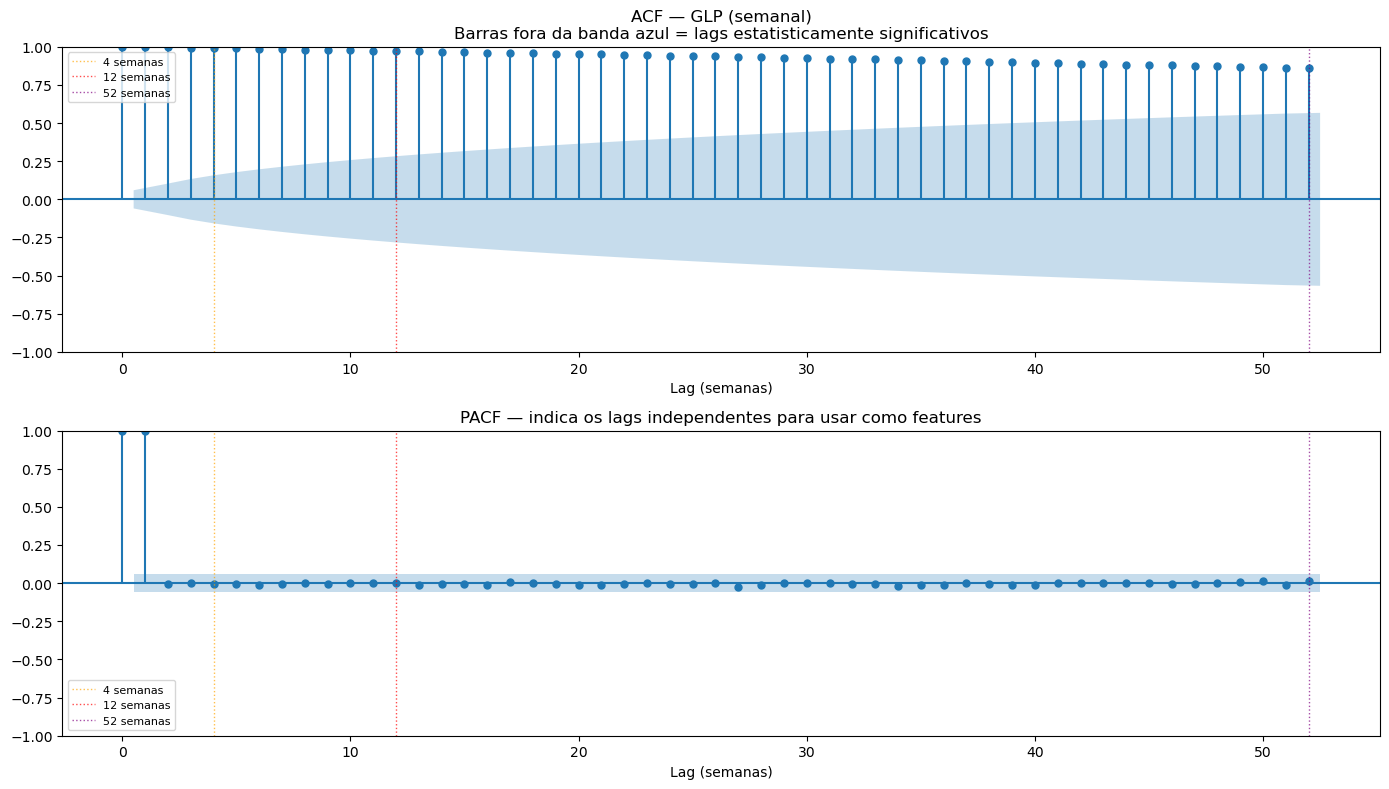

In [117]:
produto_foco = 'GLP'

# Série semanal nacional para ter mais pontos
serie_semanal = (
    df[df['Produto'] == produto_foco]
    .groupby('semana')['Valor de Venda']
    .median()
    .reset_index()
    .sort_values('semana')
    .set_index('semana')['Valor de Venda']
    .dropna()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(serie_semanal,  lags=52, ax=axes[0], alpha=0.05,
         title=f'ACF — {produto_foco} (semanal)\nBarras fora da banda azul = lags estatisticamente significativos')
plot_pacf(serie_semanal, lags=52, ax=axes[1], alpha=0.05,
          title='PACF — indica os lags independentes para usar como features')

for ax in axes:
    ax.set_xlabel('Lag (semanas)')
    ax.axvline(4,  color='orange', lw=1, linestyle=':', alpha=0.7, label='4 semanas')
    ax.axvline(12, color='red',    lw=1, linestyle=':', alpha=0.7, label='12 semanas')
    ax.axvline(52, color='purple', lw=1, linestyle=':', alpha=0.7, label='52 semanas')
    ax.legend(fontsize=8)

plt.tight_layout()
# plt.savefig('acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

No caso as distribuição é nao assimétrica, logo serão feito testes como: Mann-whitney U(comp. 2 grupos), K. Wallis (comp. 3+ grupos) e spearman p - para correlacao de opostos 

In [118]:
from scipy import stats

amostra = df[df['Produto'] == 'GLP']['Valor de Venda'].sample(5000)

# Shapiro-Wilk (até ~5k amostras)
stat, p = stats.shapiro(amostra)
print(f"Shapiro-Wilk: stat={stat:.4f}, p={p:.4f}")
print("Normal" if p > 0.05 else "NÃO normal")

# Kolmogorov-Smirnov contra distribuição normal
stat, p = stats.kstest(amostra, 'norm', args=(amostra.mean(), amostra.std()))
print(f"KS test: stat={stat:.4f}, p={p:.4f}")



Shapiro-Wilk: stat=0.7929, p=0.0000
NÃO normal
KS test: stat=0.2362, p=0.0000


## 4. Decisão Metodológica

In [119]:
# TO DO:
"""
1 - teste de normalidade por produto
2 - usar Kruskal-Wallis para comparar regiões
3 - Spearman para medir correlação com os indicadores macro

"""

'\n1 - teste de normalidade por produto\n2 - usar Kruskal-Wallis para comparar regiões\n3 - Spearman para medir correlação com os indicadores macro\n\n'

#### 4.1. Teste de normalidade por produto

In [120]:
l_products = {PRODUTOS[0]: "",PRODUTOS[1]: "",PRODUTOS[2]: "",PRODUTOS[3]: "",}
for prod in PRODUTOS:
    l_products[prod] = df[df["Produto"] == prod]["Valor de Venda"].sample(100000)

stats_prod = {"GLP":"",
              "GASOLINA":"",
              "ETANOL":"",
              "DIESEL":"",}
for i in l_products:
    stat, p_value = stats.kstest(l_products[i], 'norm', args=(l_products[i].mean(), l_products[i].std()))
    stats_prod[i] = {"stat": f"{stat:.4f}", "p-value": f"{p_value:.4f}"}
    print(f"Statistic {i}: {stat:.4f}, p-value: {p_value:.4f}")


Statistic GLP: 0.2353, p-value: 0.0000
Statistic GASOLINA: 0.1755, p-value: 0.0000
Statistic ETANOL: 0.1345, p-value: 0.0000
Statistic DIESEL: 0.1968, p-value: 0.0000


A hipótese nula do teste (H₀) é "os dados seguem distribuição normal". O p-value é a probabilidade de observar esses dados se H₀ fosse verdade. Com p = 0.0000, essa probabilidade é essencialmente zero — você rejeita H₀ com total confiança para todos os produtos. Nenhum deles é normalmente distribuído.

A statistic do KS mede a maior distância entre a distribuição acumulada dos seus dados e a de uma normal teórica. Quanto maior, mais distante da normalidade.

- GLP:      0.2351  → mais distante da normal
- DIESEL:   0.1965  → segundo mais distante  
- GASOLINA: 0.1768  → terceiro
- ETANOL:   0.1326  → menos distante, mas ainda longe

O GLP sendo o mais distante faz sentido intuitivo — o preço do gás de cozinha tem uma dinâmica diferente dos combustíveis líquidos. É vendido em botijões com peso fixo, tem subsídio governamental histórico, e a variação de preço tende a ser mais discreta (em degraus, não contínua), o que cria uma distribuição com picos em valores específicos — bem diferente de uma normal.

- Como consequência, devo seguir utilizando a comparacao entre estados, irei utilizar mannwhitneyu(p 2 grupos) ou kruskal(para 3+ grupos)

In [121]:
# df_test_kruskal = df[df["Valor de Venda"].groupby("Regiao").sum()]
series_test_kruskal = df_sample.groupby(df_sample["Regiao"])["Valor de Venda"].sum()

#### 4.1. Teste de segmentar o modelo por estado

In [122]:
top_states_sellers = df_sample["Valor de Venda"].groupby(df_sample["Estado - Sigla"]).sum()
top_states_sellers.sort_values(ascending=False).head(10)

Estado - Sigla
SP    362664.187
MG    185457.862
RS    124706.701
PR    121530.392
RJ     80809.016
GO     78475.453
BA     66563.924
SC     52096.143
PE     51744.008
CE     46808.136
Name: Valor de Venda, dtype: float64

In [123]:
df_sample = df_sample.drop(columns=["Regiao - Sigla", "Numero Rua", "Complemento","Bairro","Valor de Compra"])

In [124]:
from scipy.stats import kruskal
df_sp = df_sample[(df_sample["Estado - Sigla"] == "SP") & (df_sample["Produto"] == "GLP")]
df_mg = df_sample[(df_sample["Estado - Sigla"] == "MG") & (df_sample["Produto"] == "GLP")]
df_rs = df_sample[(df_sample["Estado - Sigla"] == "RS") & (df_sample["Produto"] == "GLP")]
df_pr = df_sample[(df_sample["Estado - Sigla"] == "PR") & (df_sample["Produto"] == "GLP")]
df_rj = df_sample[(df_sample["Estado - Sigla"] == "RJ") & (df_sample["Produto"] == "GLP")]

In [125]:
kruskal(df_sp["Valor de Venda"], df_mg["Valor de Venda"], df_rs["Valor de Venda"], df_pr["Valor de Venda"], df_rj["Valor de Venda"])

KruskalResult(statistic=60.44120565523487, pvalue=2.3431507832434972e-12)

--- No teste de normalidadeobtive H₀:  "os preços são normais" ->  p = 0.0000, rejeitou H₀

--- Utilizando KS assumi H₀ "os preços de GLP são iguais entre os estados". p = 2.34e-12, rejeitou H₀
    -- Isso confirma que a variável estado é relevante — o que justifica incluí-la como feature no modelo.

* -> Statistic H : 60.44   → valor alto, rankings muito concentrados
* -> p-value     : 2.34e-10 → probabilidade praticamente zero de ser acaso.

- Logo teste confirma que pelo menos um estado tem distribuição de preços de GLP significativamente diferente dos demais 
- As vendas do GLP se comportam de forma estatisticamente diferente entre os estados do Brasil
- Próximo passo: post-hoc de Dunn para identificar quais estados diferem entre si

In [126]:
import scikit_posthocs as sp

# Agrupa os dados num formato que o Dunn aceita
dados_glp = df_sample[
    (df_sample["Produto"] == "GLP") &
    (df_sample["Estado - Sigla"].isin(["SP", "MG", "RS", "PR", "RJ"]))
][["Estado - Sigla", "Valor de Venda"]]

# Teste de Dunn com correção de Bonferroni
resultado_dunn = sp.posthoc_dunn(
    dados_glp,
    val_col="Valor de Venda",
    group_col="Estado - Sigla",
    p_adjust="bonferroni"
)

print(resultado_dunn)

              MG        PR        RJ            RS            SP
MG  1.000000e+00  1.000000  1.000000  1.000000e+00  4.000933e-08
PR  1.000000e+00  1.000000  1.000000  1.115234e-01  6.164887e-03
RJ  1.000000e+00  1.000000  1.000000  4.054408e-01  5.359223e-02
RS  1.000000e+00  0.111523  0.405441  1.000000e+00  7.354112e-10
SP  4.000933e-08  0.006165  0.053592  7.354112e-10  1.000000e+00


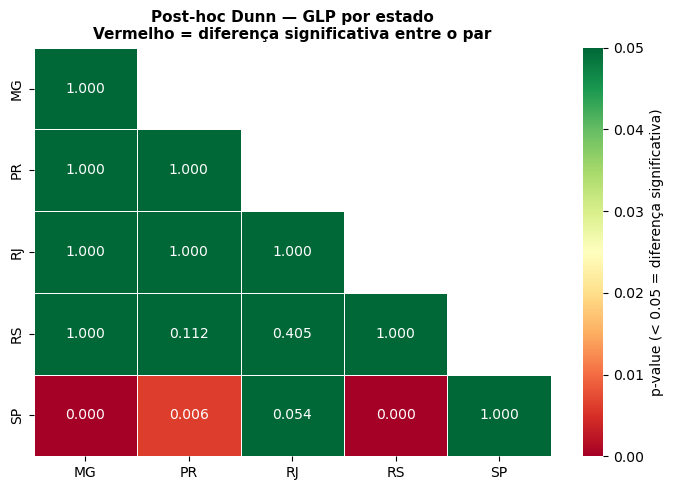

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 5))

# Máscara para o triângulo superior (evita duplicação)
mask = np.triu(np.ones_like(resultado_dunn, dtype=bool), k=1)

# Heatmap com destaque nos significativos
sns.heatmap(
    resultado_dunn,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",        # vermelho = significativo, verde = não significativo
    vmin=0, vmax=0.05,    # foco na faixa de decisão
    mask=mask,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "p-value (< 0.05 = diferença significativa)"}
)

ax.set_title(
    "Post-hoc Dunn — GLP por estado\n"
    "Vermelho = diferença significativa entre o par",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig("dunn_glp.png", dpi=150, bbox_inches="tight")
plt.show()

#### 4.2. Teste de segmentar o modelo por Estado e Região

In [128]:
top_region_sellers = df_sample["Valor de Venda"].groupby(df_sample["Regiao"]).sum()
top_region_sellers.sort_values(ascending=False).head(10)

Regiao
Sudeste         663705.811
Sul             298333.236
Nordeste        265063.866
Centro-Oeste    176377.351
Norte           151954.674
Name: Valor de Venda, dtype: float64

In [129]:
df_se = df_sample[(df_sample["Regiao"] == "Sudeste") & (df_sample["Produto"] == "GLP")]
df_sl = df_sample[(df_sample["Regiao"] == "Sul") & (df_sample["Produto"] == "GLP")]
df_ne = df_sample[(df_sample["Regiao"] == "Nordeste") & (df_sample["Produto"] == "GLP")]
df_co = df_sample[(df_sample["Regiao"] == "Centro-Oeste") & (df_sample["Produto"] == "GLP")]
df_no = df_sample[(df_sample["Regiao"] == "Norte") & (df_sample["Produto"] == "GLP")]

In [130]:
kruskal(df_se["Valor de Venda"], df_sl["Valor de Venda"], df_ne["Valor de Venda"], df_co["Valor de Venda"], df_no["Valor de Venda"])

KruskalResult(statistic=287.2165171977467, pvalue=6.193253133580676e-61)

In [131]:
import scikit_posthocs as sp

# Agrupa os dados num formato que o Dunn aceita
dados_glp = df_sample[
    (df_sample["Produto"] == "GLP") &
    (df_sample["Regiao"].isin(["Sudeste", "Sul","Nordeste","Centro-Oeste","Norte"]))
][["Regiao", "Valor de Venda"]]

# Teste de Dunn com correção de Bonferroni
resultado_dunn = sp.posthoc_dunn(
    dados_glp,
    val_col="Valor de Venda",
    group_col="Regiao",
    p_adjust="bonferroni"
)

print(resultado_dunn)

              Centro-Oeste      Nordeste         Norte       Sudeste  \
Centro-Oeste  1.000000e+00  2.585189e-19  1.000000e+00  2.957668e-39   
Nordeste      2.585189e-19  1.000000e+00  2.130772e-18  2.703617e-02   
Norte         1.000000e+00  2.130772e-18  1.000000e+00  2.177637e-35   
Sudeste       2.957668e-39  2.703617e-02  2.177637e-35  1.000000e+00   
Sul           1.006876e-18  1.000000e+00  9.552829e-18  9.306343e-04   

                       Sul  
Centro-Oeste  1.006876e-18  
Nordeste      1.000000e+00  
Norte         9.552829e-18  
Sudeste       9.306343e-04  
Sul           1.000000e+00  


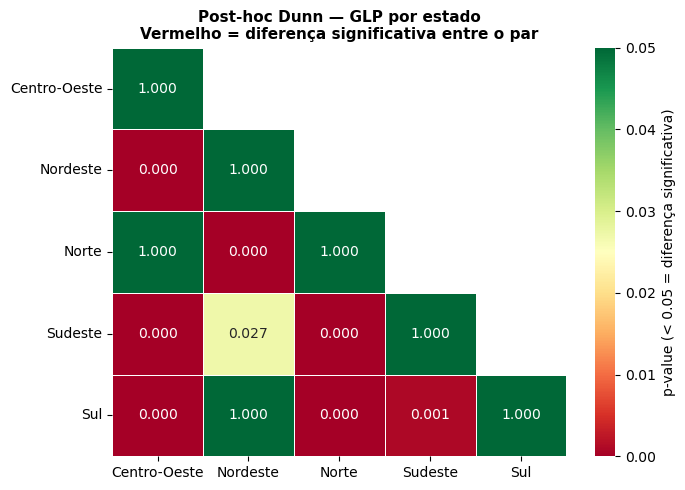

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 5))

# Máscara para o triângulo superior (evita duplicação)
mask = np.triu(np.ones_like(resultado_dunn, dtype=bool), k=1)

# Heatmap com destaque nos significativos
sns.heatmap(
    resultado_dunn,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",        # vermelho = significativo, verde = não significativo
    vmin=0, vmax=0.05,    # foco na faixa de decisão
    mask=mask,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "p-value (< 0.05 = diferença significativa)"}
)

ax.set_title(
    "Post-hoc Dunn — GLP por estado\n"
    "Vermelho = diferença significativa entre o par",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig("dunn_glp.png", dpi=150, bbox_inches="tight")
plt.show()

Podemos assumir que ocorre uma similiaridade de preços entre as seguintes regiões:
- Centro-Oeste × Nordeste  →  p = 2.59e-19  -> altamente significativo
- Centro-Oeste × Norte     →  p = 1.000000  -> sem diferença
- Centro-Oeste × Sudeste   →  p = 2.96e-39  -> altamente significativo
- Centro-Oeste × Sul       →  p = 1.01e-18  -> altamente significativo

- Nordeste     × Norte     →  p = 2.13e-18  -> altamente significativo
- Nordeste     × Sudeste   →  p = 2.70e-02  -> significativo (mas fraco)
- Nordeste     × Sul       →  p = 1.000000  -> sem diferença

- Norte        × Sudeste   →  p = 2.18e-35  -> altamente significativo
- Norte        × Sul       →  p = 9.55e-18  -> altamente significativo

- Sudeste      × Sul       →  p = 9.31e-04  -> significativo

--- 
Logo, o ideal seria segmentar em cluster:
{
    "Norte":         "cluster_A",  # preço similar ao Centro-Oeste
    "Centro-Oeste":  "cluster_A",
    "Nordeste":      "cluster_B",  # preço similar ao Sul
    "Sul":           "cluster_B",
    "Sudeste":       "cluster_C",  # comportamento isolado
}
- Mas irei criar dummies de acordo com a região, tendo em vista que o BR possui 5 regiões, o que facilita de feature para o modelo.
    Caso a acuracia seja baixa e a precisao tambem, terei que ajustar para reduzir a um nivel mais micro(Estados).

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24694411 entries, 0 to 24694410
Data columns (total 21 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Regiao - Sigla     object        
 1   Estado - Sigla     object        
 2   Municipio          object        
 3   Revenda            object        
 4   CNPJ da Revenda    object        
 5   Nome da Rua        object        
 6   Numero Rua         object        
 7   Complemento        object        
 8   Bairro             object        
 9   Cep                object        
 10  Produto            object        
 11  Data da Coleta     datetime64[ns]
 12  Valor de Venda     float64       
 13  Valor de Compra    float64       
 14  Unidade de Medida  object        
 15  Bandeira           object        
 16  ano_mes            period[M]     
 17  ano                int32         
 18  mes                int32         
 19  semana             period[W-SUN] 
 20  mes_nome           obj

In [134]:
df["Data da Coleta"].where(df["Valor de Compra"].notna()).groupby(df["Produto"]).max()

Produto
DIESEL               2020-12-31
DIESEL S10           2020-12-31
DIESEL S50           2012-08-09
ETANOL               2020-12-31
GASOLINA             2020-12-31
GASOLINA ADITIVADA   2020-12-31
GLP                  2020-12-31
GNV                  2020-12-31
Name: Data da Coleta, dtype: datetime64[ns]

In [136]:
df[df["Bandeira"].isin(["COPA ENERGIA", "COPAGAZ", ])]

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,...,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira,ano_mes,ano,mes,semana,mes_nome
16726392,SE,SP,SAO PAULO,NOVA BRASILIA GAS LTDA,03.689.847/0001-13,RUA NOVA BRASILIA,672,None,JARDIM DONA SINHA,03924-040,...,2019-01-07,57.0,48.100000,R$ / 13 kg,COPAGAZ,2019-01,2019,1,2019-01-07/2019-01-13,Jan
16726418,SE,SP,CARAPICUIBA,LUCAS & LUIZ GAS LTDA - ME,21.277.125/0001-33,ESTRADA JEQUITIBÃ,752,None,PARQUE JOSÃ ALEX ANDRÃ,06321-651,...,2019-01-07,60.0,61.480000,R$ / 13 kg,COPAGAZ,2019-01,2019,1,2019-01-07/2019-01-13,Jan
16726451,SE,SP,POA,E E DA SILVA GÃS - ME,24.073.028/0001-17,RUA MEM DE SA,378,None,VILA SANTA HELENA,08553-550,...,2019-01-07,60.0,53.800000,R$ / 13 kg,COPAGAZ,2019-01,2019,1,2019-01-07/2019-01-13,Jan
16726470,SE,SP,SUZANO,CARVALHO COMERCIO VAREJISTA DE GLP LTDA,13.214.567/0001-02,AVENIDA BRASILIA,408,None,VILA AMORIM,08610-100,...,2019-01-07,59.0,47.560000,R$ / 13 kg,COPAGAZ,2019-01,2019,1,2019-01-07/2019-01-13,Jan
16726472,SE,SP,SUZANO,CABOCLOS COMERCIO DE GAS LTDA - ME,66.891.029/0001-19,RUA CABOCLOS,202,None,JARDIM SANTA LUCIA,08615-190,...,2019-01-07,65.0,55.776923,R$ / 13 kg,COPAGAZ,2019-01,2019,1,2019-01-07/2019-01-13,Jan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24694249,S,RS,PORTO ALEGRE,CENTRAL GAS LTDA,49.798.139/0001-11,AVENIDA SATURNINO DE BRITO,482,None,VILA JARDIM,91200-000,...,2026-03-31,110.0,NaN,R$ / 13 kg,COPA ENERGIA,2026-03,2026,3,2026-03-30/2026-04-05,Mar
24694282,S,RS,PELOTAS,GAS UNIAO COMERCIO VAREJISTA DE GLP LTDA,17.414.792/0001-43,RUA PROFESSOR PAULO ZANOTTA DA CRUZ,738,CASA 02,FRAGATA,96050-000,...,2026-03-31,115.0,NaN,R$ / 13 kg,COPA ENERGIA,2026-03,2026,3,2026-03-30/2026-04-05,Mar
24694292,S,RS,SANTA CRUZ DO SUL,SIM REDE DE POSTOS LTDA,07.473.735/0140-50,RUA ERNESTO ALVES,1635,None,CENTRO,96810-346,...,2026-03-31,118.0,NaN,R$ / 13 kg,COPA ENERGIA,2026-03,2026,3,2026-03-30/2026-04-05,Mar
24694293,S,RS,SANTA CRUZ DO SUL,ISERGAS PRESTADORA DE SERVICOS LTDA,02.735.524/0001-56,RODOVIA BR-471,SN,KM 141.650,VARZEA,96814-000,...,2026-03-31,115.0,NaN,R$ / 13 kg,COPA ENERGIA,2026-03,2026,3,2026-03-30/2026-04-05,Mar
